# Визуализация данных

Бабошин Никита Андреевич (6401-010302D)

### Считать в `pandas.DataFrame` любой источник данных: CSV, JSON, Excel-файл, HTML-таблицу и т.п.
Также можно сконвертировать в DataFrame любой из встроенных датасетов `sklearn`: (см. [инструкцию](https://stackoverflow.com/questions/38105539/how-to-convert-a-scikit-learn-dataset-to-a-pandas-dataset)).  

   > Главное условие к датасету, который вы загружаете &ndash; там должны быть как минимум пара числовых колонок и как минимум одна категориальная с небольшим числом категорий.

Ссылка на источник данных: https://www.kaggle.com/datasets/ankitverma2010/ecommerce-customer-churn-analysis-and-prediction

In [1]:
import pandas as pd

df = pd.read_excel('data/E Commerce Dataset.xlsx', sheet_name='E Comm', usecols='A:T')
df.head()

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


### Привести описание датасета.  

   Пример.  
   Датасет содержит данные о метеонаблюдениях в Австралии, цель (целевой признак, таргет) &ndash; прогнозирование дождя на следующий день.  
   | Признак | Описание | Единицы измерения |  
   | --- | --- | --- |  
   | Location | The common name of the location of the weather station |  
   | MinTemp | Minimum temperature in the 24 hours to 9am. Sometimes only known to the nearest whole degree. | degrees Celsius  
   | Sunshine | Bright sunshine in the 24 hours to midnight | hours

Описание датасета:

Датасет "Ecommerce Customer Churn Analysis and Prediction" содержит данные, собранные ведущей онлайн-компанией электронной коммерции для анализа и прогнозирования оттока клиентов (churn). В нём представлены различные признаки клиентов, включая уникальный идентификатор, флаг оттока, срок сотрудничества с компанией и т.п. Цель датасета — выявить клиентов, которые, вероятно, прекратят пользоваться услугами, чтобы компания могла предложить им специальные промо-акции и удержать.

Целевой признак: Churn

In [2]:
dictData = pd.read_excel('data/E Commerce Dataset.xlsx', sheet_name='Data Dict', usecols='C:D', skiprows=1)
dictData

,Variable,Discerption
0,CustomerID,Unique customer ID
1,Churn,Churn Flag
2,Tenure,Tenure of customer in organization
3,PreferredLoginDevice,Preferred login device of customer
4,CityTier,City tier
5,WarehouseToHome,Distance in between warehouse to home of customer
6,PreferredPaymentMode,Preferred payment method of customer
7,Gender,Gender of customer
8,HourSpendOnApp,Number of hours spend on mobile application or...
9,NumberOfDeviceRegistered,Total number of deceives is registered on part...


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   object 
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   object 
 7   Gender                       5630 non-null   object 
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   object 
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   object 
 13  NumberOfAddress   

## matplotlib

- Построить несколько графиков разного вида с использованием `matplotlib`.  
- Построить несколько суб-графиков на одном графике используя `.subplot`.  
- Построить интерактивный график со слайдером.

> - Графики должны быть разных видов.  
> - Хотя бы в одном графике необходимо подписать оси.  
> - Во всех графиках необходимо указать название.
> - Необязательно строить сложный и перегруженный информацией интерактивный график, достаточноодного-двух числовых признаков в разрезе другого признака, как минимум добавить слайдер (ползунок).Наличие других графических элементов управления (кнопки и т.п.) &ndash; опционально.

### Построить несколько графиков разного вида с использованием `matplotlib`.  

#### Круговая диаграмма
Показывает долю клиентов, которые ушли и которые остались.

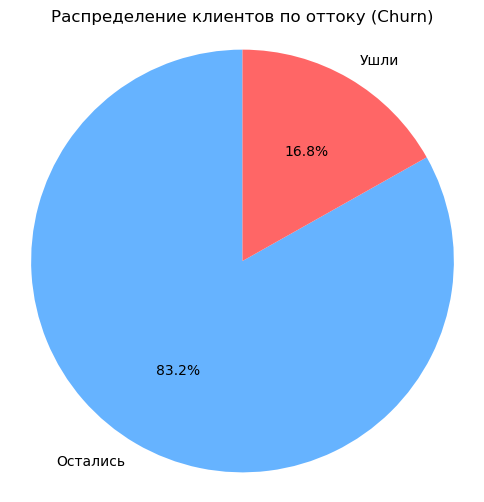

In [4]:
import matplotlib.pyplot as plt

churn_counts = [ (df['Churn'] == 0).sum(), (df['Churn'] == 1).sum() ]
labels = ['Остались', 'Ушли']

plt.figure(figsize=(6, 6))
plt.pie(churn_counts, labels=labels, autopct='%1.1f%%', startangle=90, colors=['#66b3ff', '#ff6666'])
plt.title('Распределение клиентов по оттоку (Churn)')
plt.axis('equal')

plt.show()

#### Гистограмма
Отображает распределение времени пребывания клиентов.

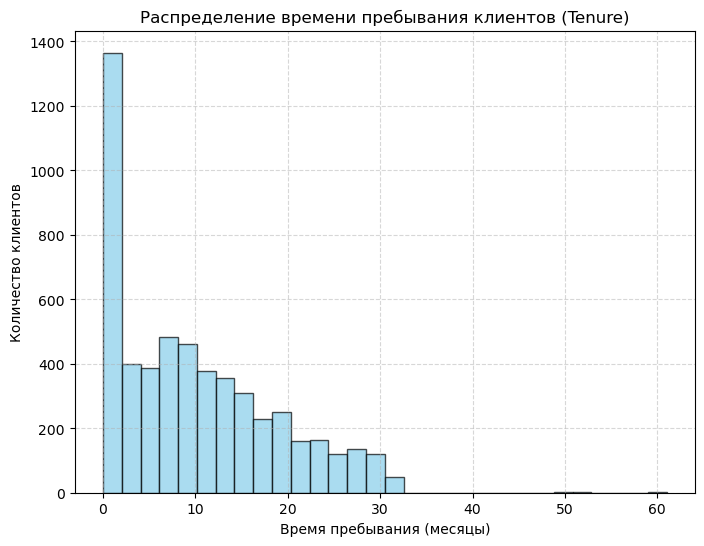

In [5]:
plt.figure(figsize=(8, 6))
plt.hist(df['Tenure'], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Распределение времени пребывания клиентов (Tenure)')
plt.xlabel('Время пребывания (месяцы)')
plt.ylabel('Количество клиентов')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

#### Линейный график
Показывает изменение среднего количества заказов с ростом времени клиента, отдельно для ушедших и оставшихся.

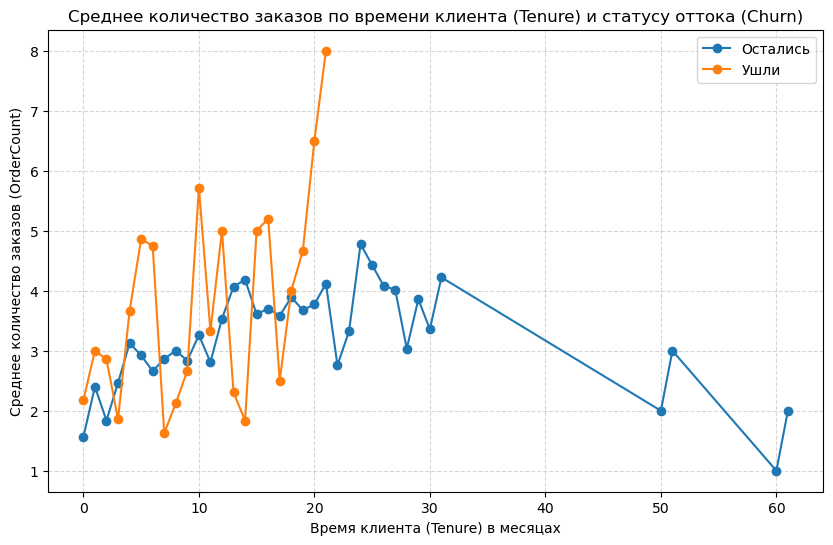

In [6]:
df_clean = df.dropna(subset=['Tenure', 'OrderCount', 'Churn'])

grouped = df_clean.groupby(['Churn', 'Tenure'])['OrderCount'].mean().reset_index()

plt.figure(figsize=(10, 6))

for churn_status, group_data in grouped.groupby('Churn'):
    label = 'Ушли' if churn_status == 1 else 'Остались'
    plt.plot(group_data['Tenure'], group_data['OrderCount'], marker='o', label=label)

plt.title('Среднее количество заказов по времени клиента (Tenure) и статусу оттока (Churn)')
plt.xlabel('Время клиента (Tenure) в месяцах')
plt.ylabel('Среднее количество заказов (OrderCount)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

#### Столбчатая диаграмма
Частота разных способов оплаты.

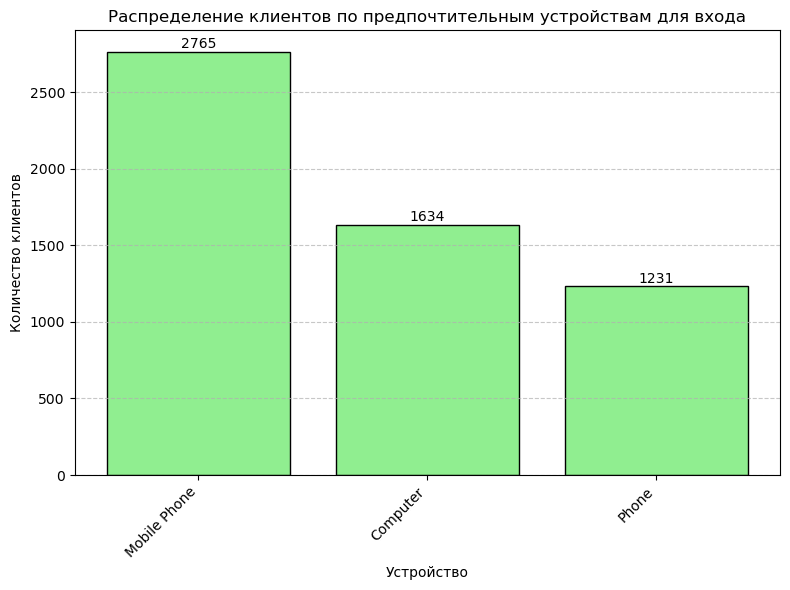

In [7]:
device_counts = df['PreferredLoginDevice'].value_counts()

devices = device_counts.index
counts = device_counts.values

plt.figure(figsize=(8, 6))
bars = plt.bar(devices, counts, color='lightgreen', edgecolor='black')

plt.title('Распределение клиентов по предпочтительным устройствам для входа')
plt.xlabel('Устройство')
plt.ylabel('Количество клиентов')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 5, int(height), ha='center', va='bottom')

plt.tight_layout()
plt.show()

### Построить несколько суб-графиков на одном графике используя `.subplot`.

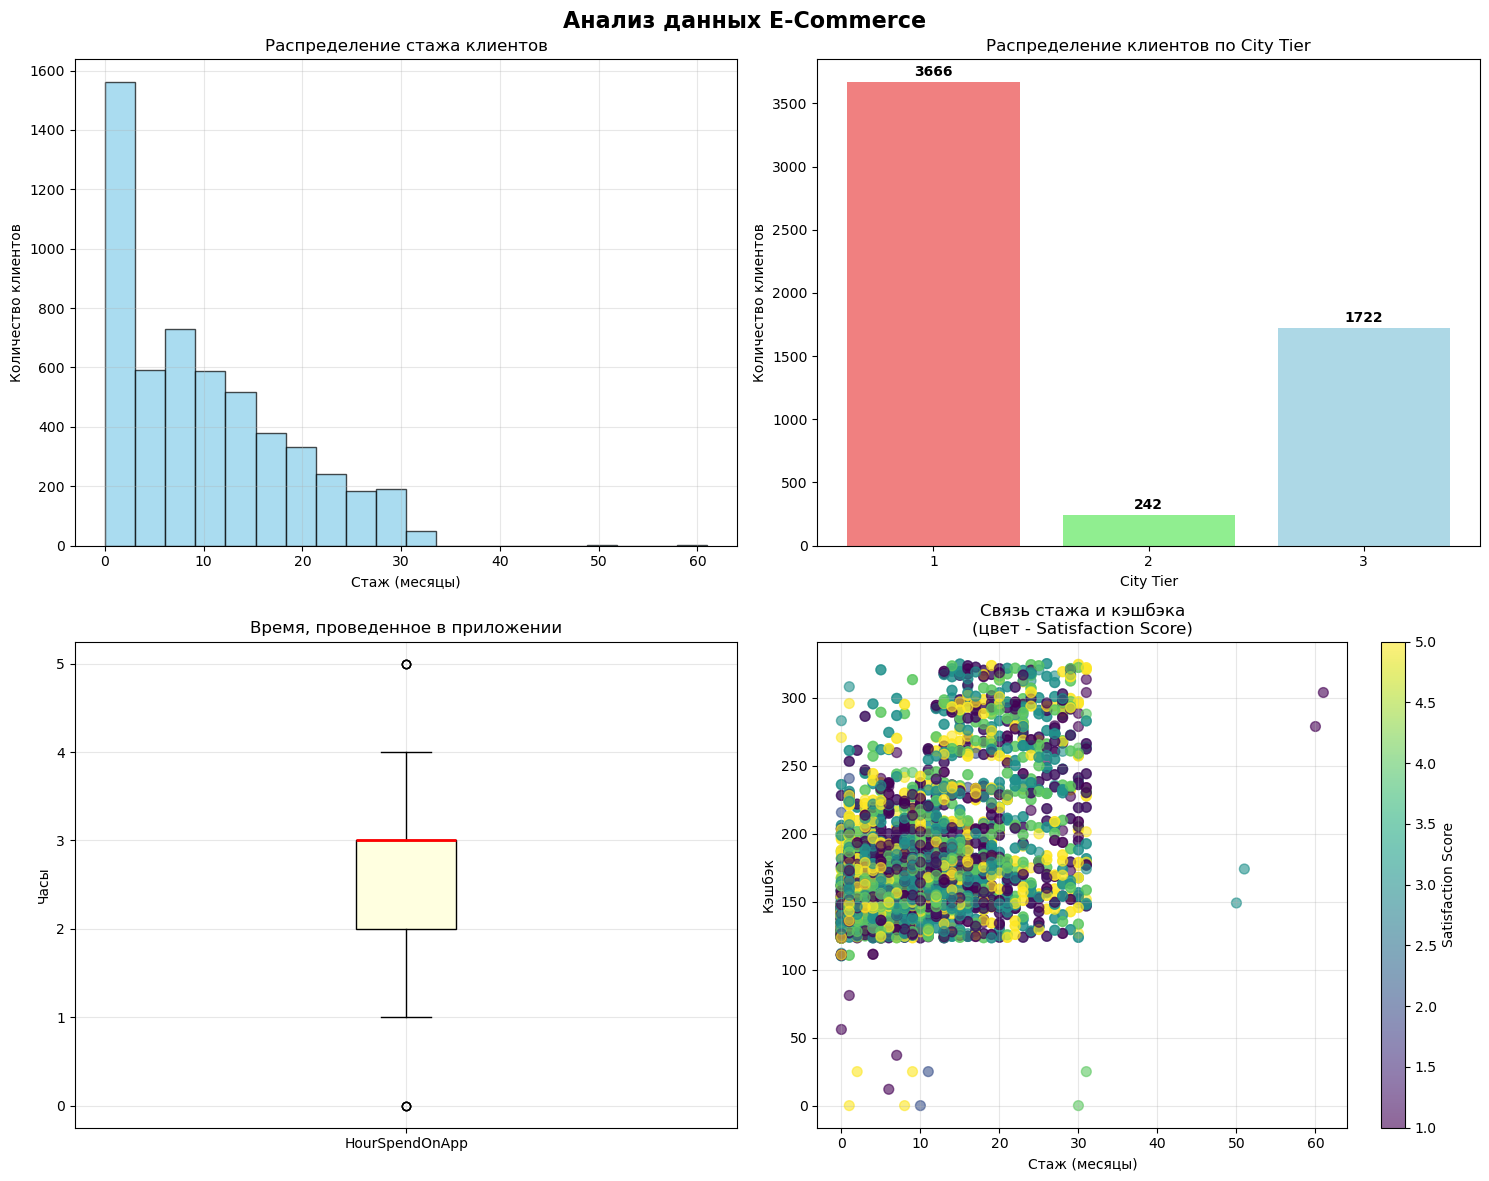

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Анализ данных E-Commerce', fontsize=16, fontweight='bold')

# Гистограмма для числового признака - Tenure
axes[0, 0].hist(df['Tenure'].dropna(), bins=20, edgecolor='black', alpha=0.7, color='skyblue')
axes[0, 0].set_title('Распределение стажа клиентов')
axes[0, 0].set_xlabel('Стаж (месяцы)')
axes[0, 0].set_ylabel('Количество клиентов')
axes[0, 0].grid(True, alpha=0.3)

# Столбчатая диаграмма для категориального признака - CityTier
city_tier_counts = df['CityTier'].value_counts().sort_index()
axes[0, 1].bar(city_tier_counts.index, city_tier_counts.values, color=['lightcoral', 'lightgreen', 'lightblue'])
axes[0, 1].set_title('Распределение клиентов по City Tier')
axes[0, 1].set_xlabel('City Tier')
axes[0, 1].set_ylabel('Количество клиентов')
axes[0, 1].set_xticks(city_tier_counts.index)
for i, v in enumerate(city_tier_counts.values):
    axes[0, 1].text(i + 1, v + 50, str(v), ha='center', fontweight='bold')

# Box plot для числового признака - HourSpendOnApp
axes[1, 0].boxplot(df['HourSpendOnApp'].dropna(), patch_artist=True,
                   boxprops=dict(facecolor='lightyellow'),
                   medianprops=dict(color='red', linewidth=2))
axes[1, 0].set_title('Время, проведенное в приложении')
axes[1, 0].set_ylabel('Часы')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_xticks([1])
axes[1, 0].set_xticklabels(['HourSpendOnApp'])

# Scatter plot для связи двух числовых признаков
scatter = axes[1, 1].scatter(df['Tenure'], df['CashbackAmount'], 
                             c=df['SatisfactionScore'], cmap='viridis', 
                             alpha=0.6, s=50)
axes[1, 1].set_title('Связь стажа и кэшбэка\n(цвет - Satisfaction Score)')
axes[1, 1].set_xlabel('Стаж (месяцы)')
axes[1, 1].set_ylabel('Кэшбэк')
axes[1, 1].grid(True, alpha=0.3)
cbar = plt.colorbar(scatter, ax=axes[1, 1])
cbar.set_label('Satisfaction Score')

plt.tight_layout()
plt.show()

### Построить интерактивный график со слайдером.

In [30]:
#%matplotlib widget

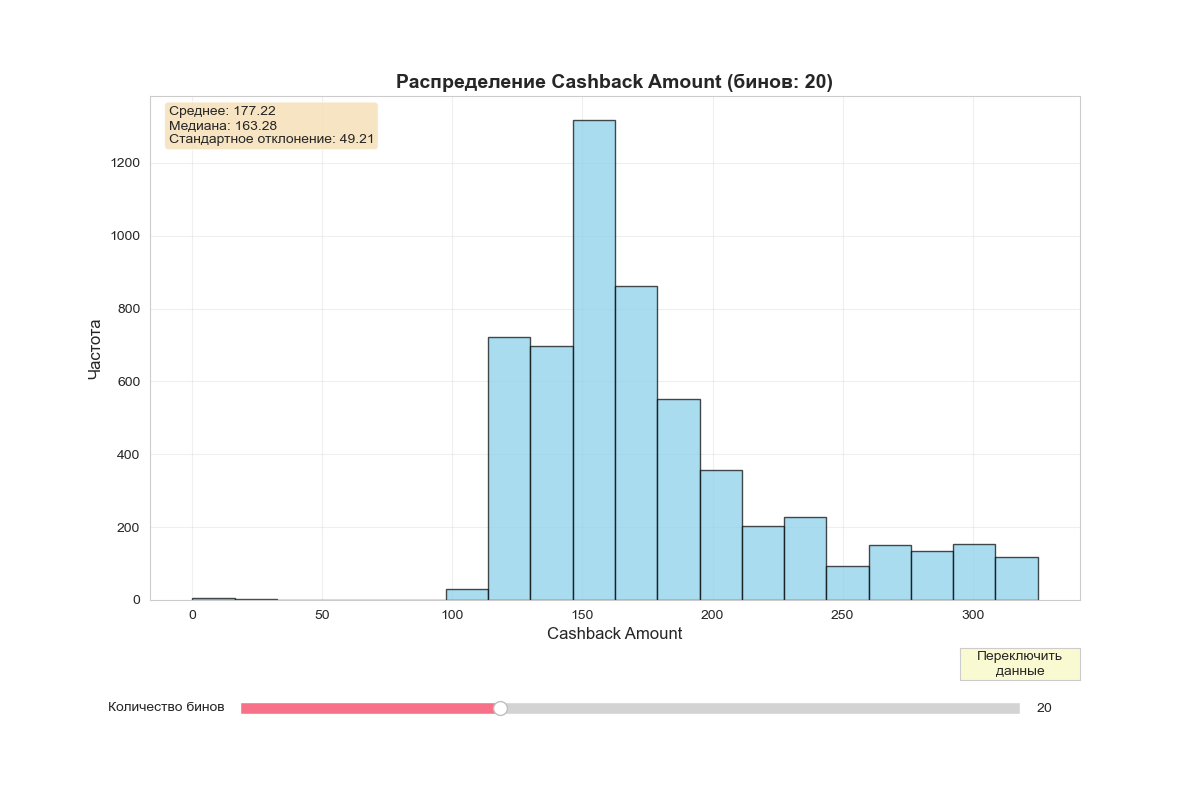

In [31]:
from matplotlib.widgets import Slider, Button

df_clean = df.copy()
df_clean['CashbackAmount'] = df_clean['CashbackAmount'].fillna(df_clean['CashbackAmount'].median())

# Создаем фигуру и оси
fig, ax = plt.subplots(figsize=(12, 8))
plt.subplots_adjust(bottom=0.25)

# Начальные значения
initial_bins = 20
data = df_clean['CashbackAmount']

# Создаем гистограмму
n, bins, patches = ax.hist(data, bins=initial_bins, edgecolor='black', 
                           alpha=0.7, color='skyblue')
ax.set_xlabel('Cashback Amount', fontsize=12)
ax.set_ylabel('Частота', fontsize=12)
ax.set_title(f'Распределение Cashback Amount (бинов: {initial_bins})', 
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

# Добавляем статистику
stats_text = f'Среднее: {data.mean():.2f}\n'
stats_text += f'Медиана: {data.median():.2f}\n'
stats_text += f'Стандартное отклонение: {data.std():.2f}'
ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, 
        verticalalignment='top', 
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# Создаем слайдер для количества бинов
ax_slider = plt.axes([0.2, 0.1, 0.65, 0.03])
slider = Slider(ax_slider, 'Количество бинов', 5, 50, valinit=initial_bins, valstep=1)

# Создаем кнопку для переключения между CashbackAmount и Tenure
ax_button = plt.axes([0.8, 0.15, 0.1, 0.04])
toggle_button = Button(ax_button, 'Переключить\nданные', color='lightgoldenrodyellow')

# Переменная для отслеживания текущих данных
current_data = 'CashbackAmount'

# Функция обновления гистограммы
def update_histogram(bins_count, data_column):
    ax.clear()
    data = df_clean[data_column].dropna()
    
    n, bins, patches = ax.hist(data, bins=int(bins_count), edgecolor='black', 
                               alpha=0.7, color='skyblue')
    ax.set_xlabel(data_column, fontsize=12)
    ax.set_ylabel('Частота', fontsize=12)
    ax.set_title(f'Распределение {data_column} (бинов: {int(bins_count)})', 
                 fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    # Обновляем статистику
    stats_text = f'Среднее: {data.mean():.2f}\n'
    stats_text += f'Медиана: {data.median():.2f}\n'
    stats_text += f'Стандартное отклонение: {data.std():.2f}'
    ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, 
            verticalalignment='top', 
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    fig.canvas.draw_idle()

# Функция обновления при изменении слайдера
def update(val):
    update_histogram(slider.val, current_data)

# Функция переключения данных
def toggle_data(event):
    global current_data
    if current_data == 'CashbackAmount':
        current_data = 'Tenure'
    else:
        current_data = 'CashbackAmount'
    update_histogram(slider.val, current_data)

# Подключаем события
slider.on_changed(update)
toggle_button.on_clicked(toggle_data)

plt.show()

In [11]:
#%matplotlib inline

## pandas

- Построить три разных вида графиков с использованием `pandas.DataFrame.plot` / `Series.plot`.  

> - Среди графиков должен присутствовать один `boxplot` (обязательно надо использовать параметр `by` для исследования взаимосвязи числовойпеременной и какой-либо другой).  
> - Графики должны быть построены как через методы `DataFrame`, так и через методы `Series`. То есть оба варианта нужно продемонстрировать.

### Построить три разных вида графиков с использованием pandas.DataFrame.plot / Series.plot.

#### Boxplot (через DataFrame)
Исследование CashbackAmount в зависимости от CityTier

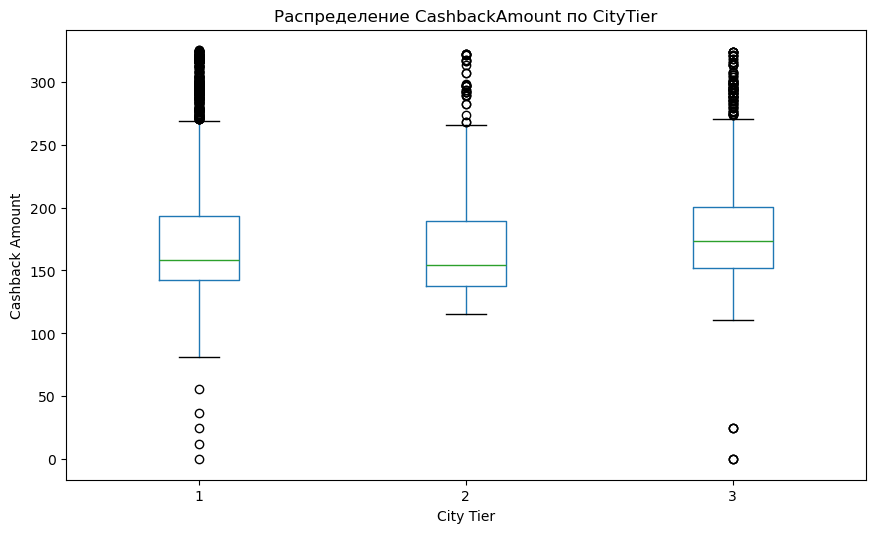

In [9]:
df.boxplot(column='CashbackAmount', by='CityTier', 
           grid=False, figsize=(10, 6))
plt.title('Распределение CashbackAmount по CityTier')
plt.suptitle('')
plt.xlabel('City Tier')
plt.ylabel('Cashback Amount')
plt.show()

#### Линейный график (через Series)
Динамика среднего CashbackAmount по Tenure

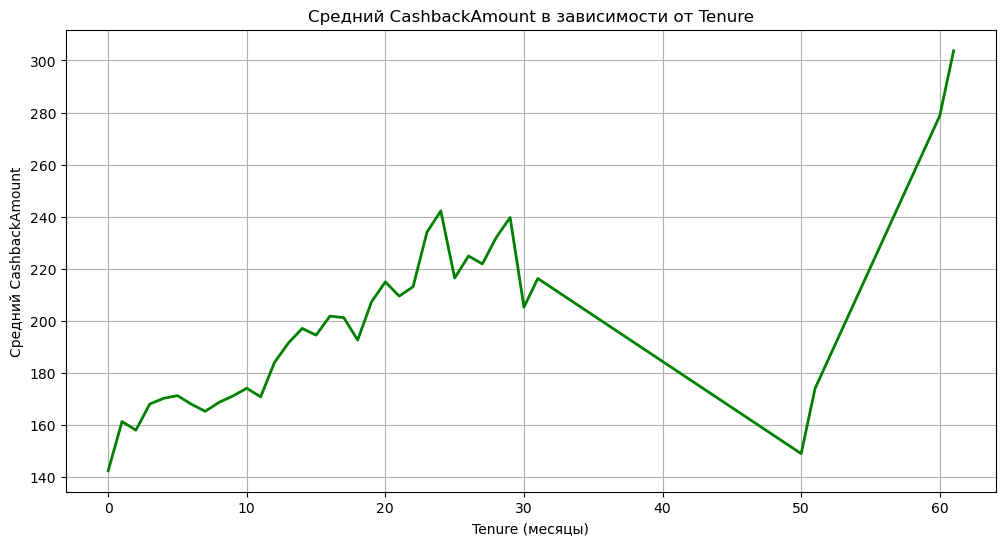

In [10]:
avg_cashback_by_tenure = df.groupby('Tenure')['CashbackAmount'].mean()

avg_cashback_by_tenure.plot(kind='line', 
                            figsize=(12, 6),
                            title='Средний CashbackAmount в зависимости от Tenure',
                            grid=True,
                            color='green',
                            linewidth=2)
plt.xlabel('Tenure (месяцы)')
plt.ylabel('Средний CashbackAmount')
plt.show()

#### Столбчатая диаграмма (через DataFrame)

Средния числовых показателей значения по полу

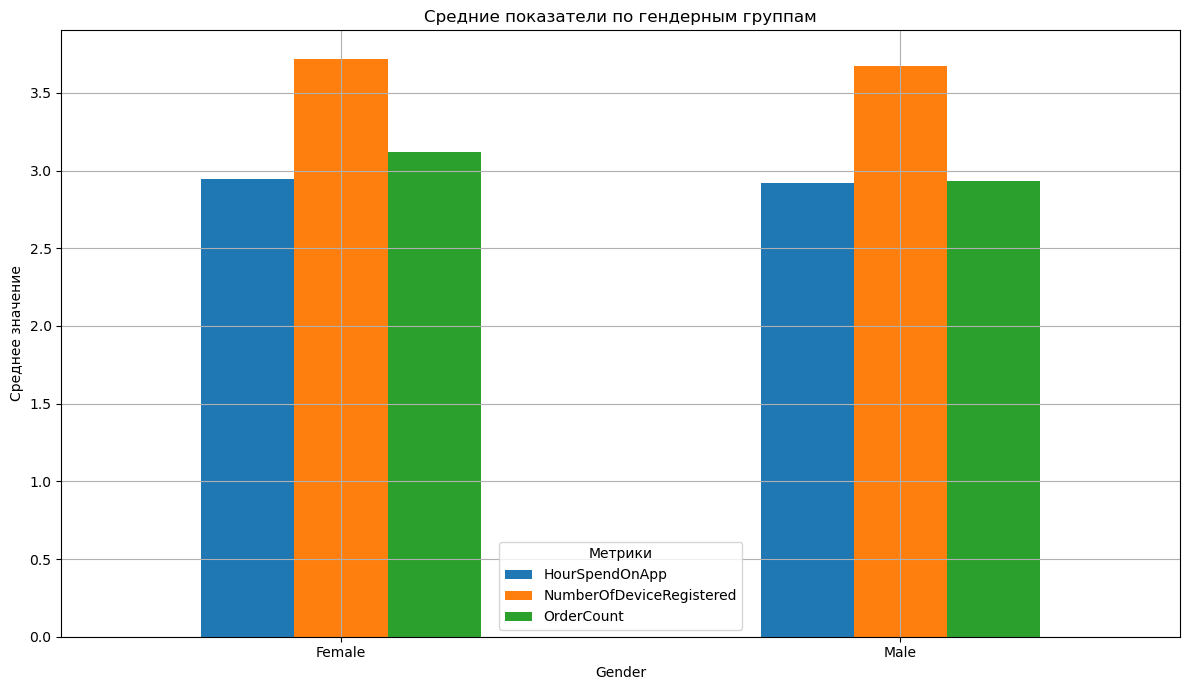

In [11]:
gender_avg = df.groupby('Gender').agg({
    'HourSpendOnApp': 'mean',
    'NumberOfDeviceRegistered': 'mean',
    'OrderCount': 'mean'
})

gender_avg.plot(kind='bar', 
                figsize=(12, 7),
                title='Средние показатели по гендерным группам',
                grid=True,
                rot=0)
plt.xlabel('Gender')
plt.ylabel('Среднее значение')
plt.legend(title='Метрики')
plt.tight_layout()
plt.show()

#### Гистограмма (через Series.hist)

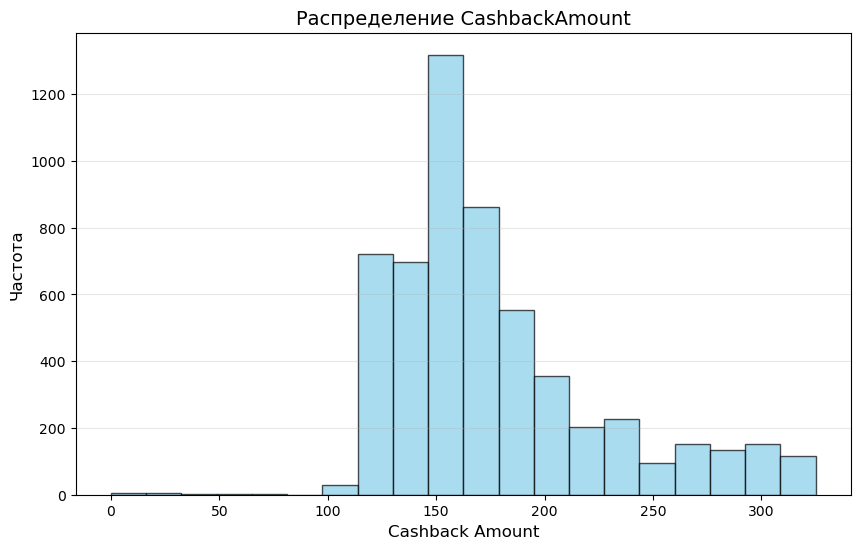

In [12]:
df['CashbackAmount'].hist(figsize=(10, 6),
                         bins=20,
                         color='skyblue',
                         edgecolor='black',
                         alpha=0.7,
                         grid=False)

plt.title('Распределение CashbackAmount', fontsize=14)
plt.xlabel('Cashback Amount', fontsize=12)
plt.ylabel('Частота', fontsize=12)
plt.grid(True, alpha=0.3, axis='y')
plt.show()

## seaborn

- Построить `.pairplot` на каком-либо наборе данных, проанализировать взаимосвязь набора числовых признаков.  
- Построить `.jointplot`, проанализировать взаимосвязь двух конкретных числовых признаков.  
- Построить `.boxplot` и/или `.violinplot` на каком-либо наборе данных, проанализировать числовой признак в разрезе категориального.  
- Построить график `.heatmap` попарной корреляции всех числовых признаков.

  > Категориальные признаки необходимо убрать из датафрейма перед построением.  

In [13]:
import seaborn as sns
# настройка стиля
sns.set_style("whitegrid")
sns.set_palette("husl")

### Построить .pairplot на каком-либо наборе данных, проанализировать взаимосвязь набора числовых признаков.

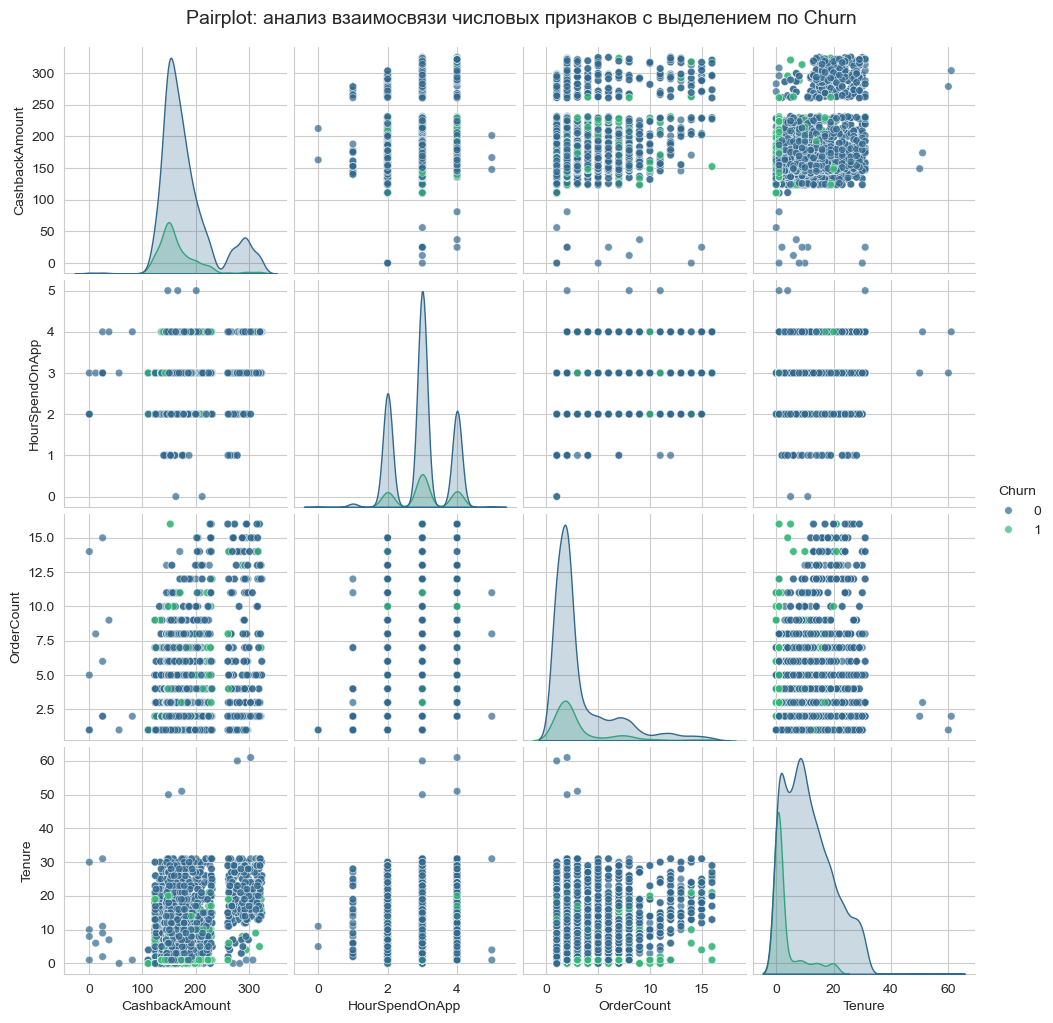

In [14]:
selected_cols = ['CashbackAmount', 'HourSpendOnApp', 'OrderCount', 'Tenure', 'Churn']
pairplot_data = df[selected_cols].dropna()

pairplot_fig = sns.pairplot(data=pairplot_data,
                            hue='Churn',
                            palette='viridis',
                            diag_kind='kde',  # kde вместо hist на диагонали
                            plot_kws={'alpha': 0.7, 's': 30},
                            height=2.5)

pairplot_fig.fig.suptitle('Pairplot: анализ взаимосвязи числовых признаков с выделением по Churn', 
                          y=1.02, fontsize=14)
plt.show()

- **Отток (зелёный)**: Скапливается в левом нижнем углу графиков (низкий Tenure, OrderCount, HourSpendOnApp).
- **Лояльность (синий)**: Распределена в правой верхней части (высокие значения всех ключевых признаков).

Это подтверждает, что активность и длительность взаимодействия — главные факторы, определяющие удержание пользователей.

### Построить .jointplot, проанализировать взаимосвязь двух конкретных числовых признаков.

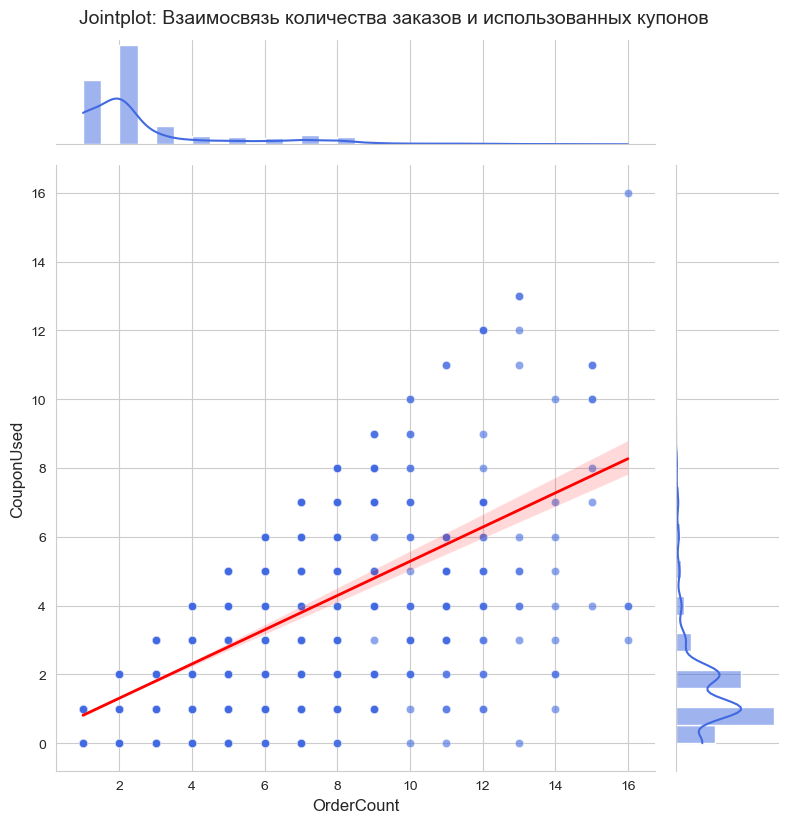

In [16]:
joint_grid = sns.jointplot(data=df.dropna(),
                           x='OrderCount',
                           y='CouponUsed',
                           kind='scatter',
                           height=8,
                           ratio=5,
                           space=0.2,
                           alpha=0.6,
                           color='royalblue',
                           marginal_kws={'bins': 30, 'kde': True})

joint_grid.ax_joint.set_xlabel('Количество заказов', fontsize=12)
joint_grid.ax_joint.set_ylabel('Количество купонов', fontsize=12)
joint_grid.fig.suptitle('Jointplot: Взаимосвязь количества заказов и использованных купонов', 
                       y=1.02, fontsize=14)

# Добавим линию регрессии
sns.regplot(data=df.dropna(),
            x='OrderCount',
            y='CouponUsed',
            ax=joint_grid.ax_joint,
            scatter=False,
            color='red',
            line_kws={'linewidth': 2})

plt.show()

- С увеличением OrderCount растет CouponUsed (точки тянутся вверх-вправо). Линия регресии подтверждает положительную корреляцию.
- Точки не строго следуют линии регрессии — сильный разброс, особенно при высоких значениях OrderCount. Это указывает на умеренную линейную связь.

Это логично. Чем больше пользователь делает заказо, тем больше он использует купонов, и наоборот.

Из матрицы корреляции ниже можно увидеть значение: 0,75

### Построить .boxplot и/или .violinplot на каком-либо наборе данных, проанализировать числовой признак в разрезе категориального.

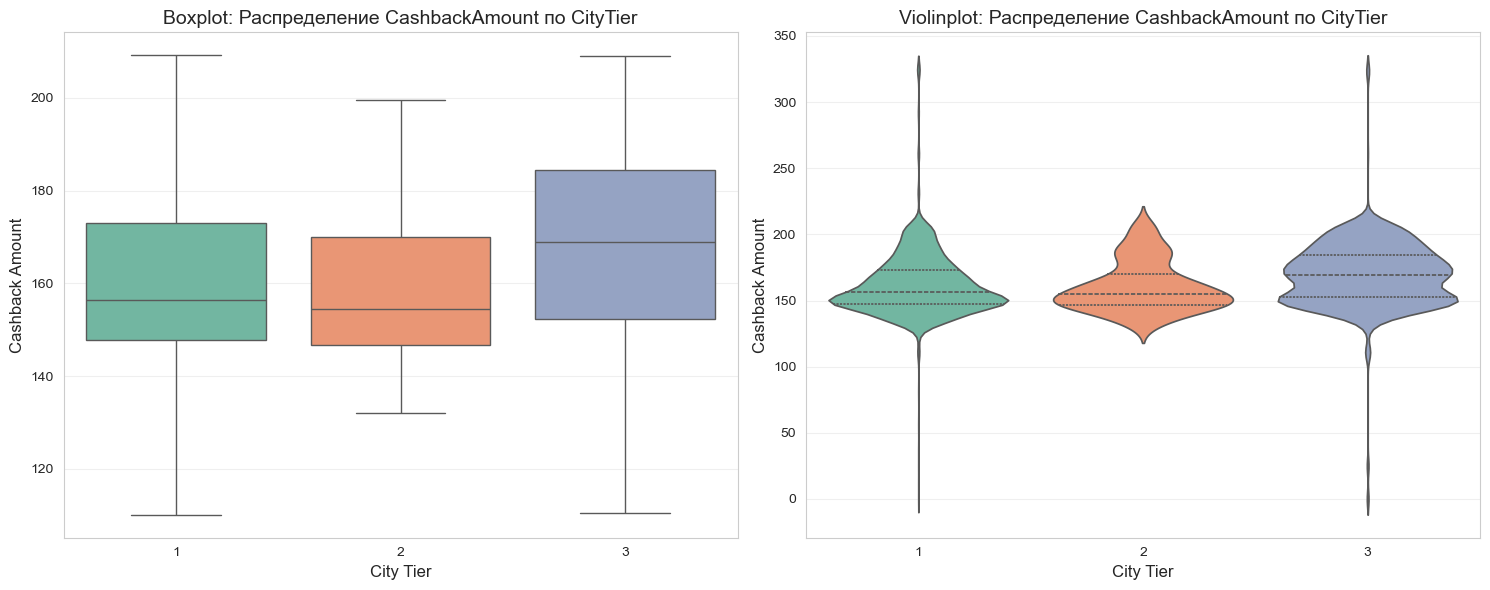

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Boxplot
sns.boxplot(data=df.dropna(),
            x='CityTier',
            y='CashbackAmount',
            ax=axes[0],
            hue='CityTier',
            palette='Set2',
            showfliers=False,
            legend=False)

axes[0].set_title('Boxplot: Распределение CashbackAmount по CityTier', fontsize=14)
axes[0].set_xlabel('City Tier', fontsize=12)
axes[0].set_ylabel('Cashback Amount', fontsize=12)
axes[0].grid(True, alpha=0.3, axis='y')

# Violinplot
sns.violinplot(data=df.dropna(),
               x='CityTier',
               y='CashbackAmount',
               ax=axes[1],
               hue='CityTier',
               palette='Set2',
               inner='quartile',
               legend=False)

axes[1].set_title('Violinplot: Распределение CashbackAmount по CityTier', fontsize=14)
axes[1].set_xlabel('City Tier', fontsize=12)
axes[1].set_ylabel('Cashback Amount', fontsize=12)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

Города Tier 3 (голубой):
- Наиболее выгодные для пользователей с точки зрения кэшбэка (высокая медиана),
- Но высокая вариативность указывает на сегментацию:
    - Одна группа активно использует кэшбэк (160–180),
    - Другая — почти не использует (100–120).

Города Tier 2 (оранжевый):
- Самые низкие значения кэшбэка,
- Стабильность указывает на отсутствие значимых программ лояльности или низкую активность пользователей.

Города Tier 1 (зеленый):
- Промежуточные показатели,
- Высокая вариативность — вероятно, смешанная аудитория (активные и пассивные пользователи).

### Построить график .heatmap попарной корреляции всех числовых признаков.

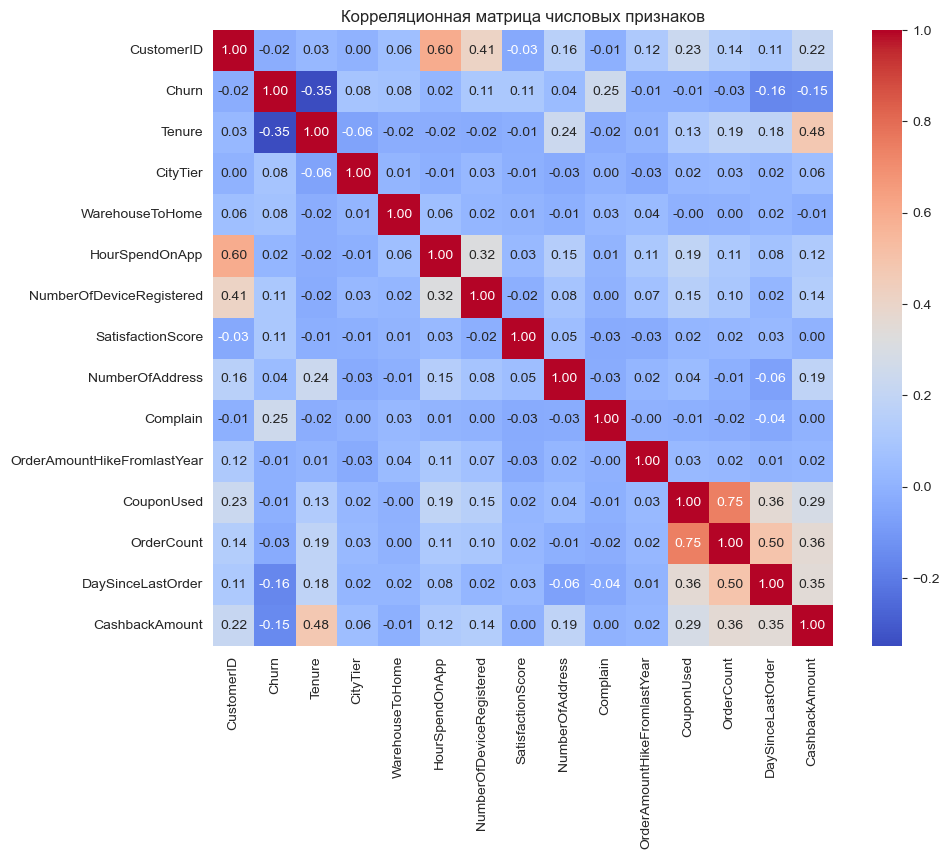

In [18]:
plt.figure(figsize=(10,8))
corr = df.select_dtypes(include='number').corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Корреляционная матрица числовых признаков')
plt.show()

## scipy.stats

- Построить QQ-график (и гистограмму) для одного из числовых признаков с целью проверки на соответствие его распределения нормальному распределению. 

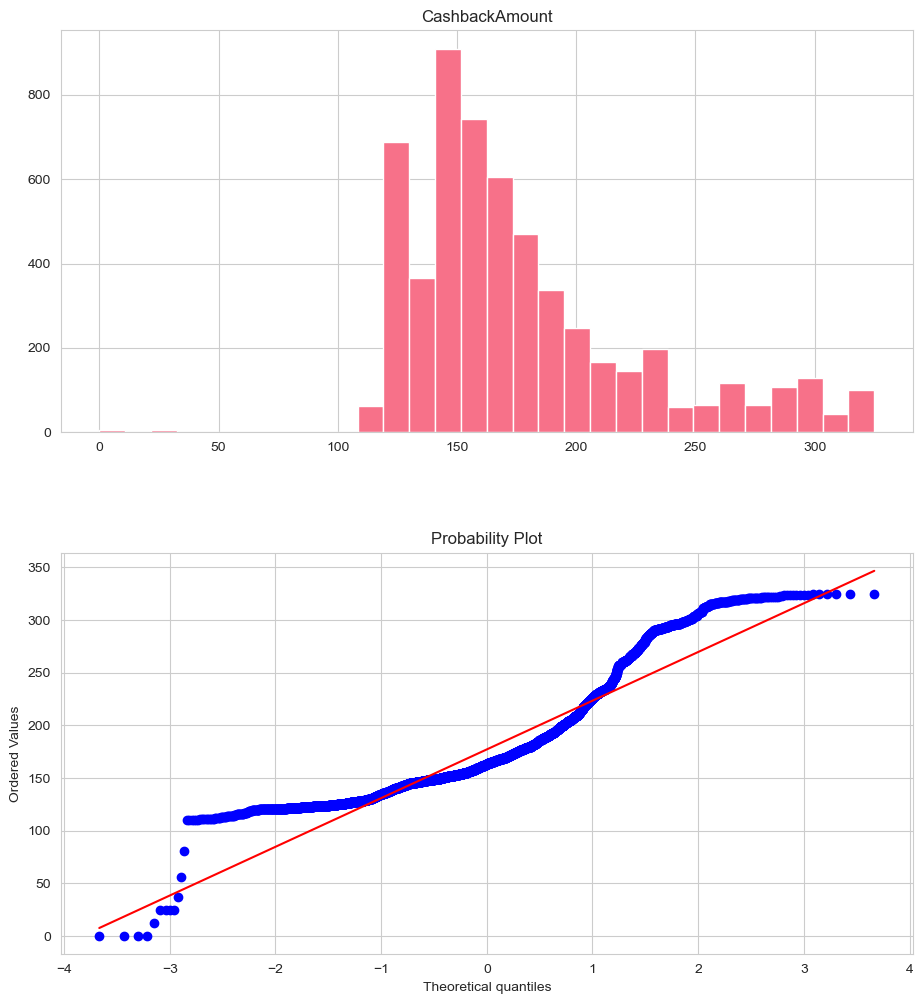

In [19]:
from scipy import stats

fig_p, ax_p = plt.subplots(2, 1, figsize=(11, 12))
stats.probplot( df['CashbackAmount'], dist="norm", plot=plt)
plt.subplot(2,1,2)
df.hist(ax = ax_p[0], column = 'CashbackAmount', bins = 30 )
plt.show()

## plotly

- Построить несколько графиков разного вида.  
- Построить несколько суб-графиков на одном графике.  
- Построить интерактивный график.  

  > Использование `Dash` опционально.

###  Построить несколько графиков разного вида.

#### Круговая диаграмма (Churn)

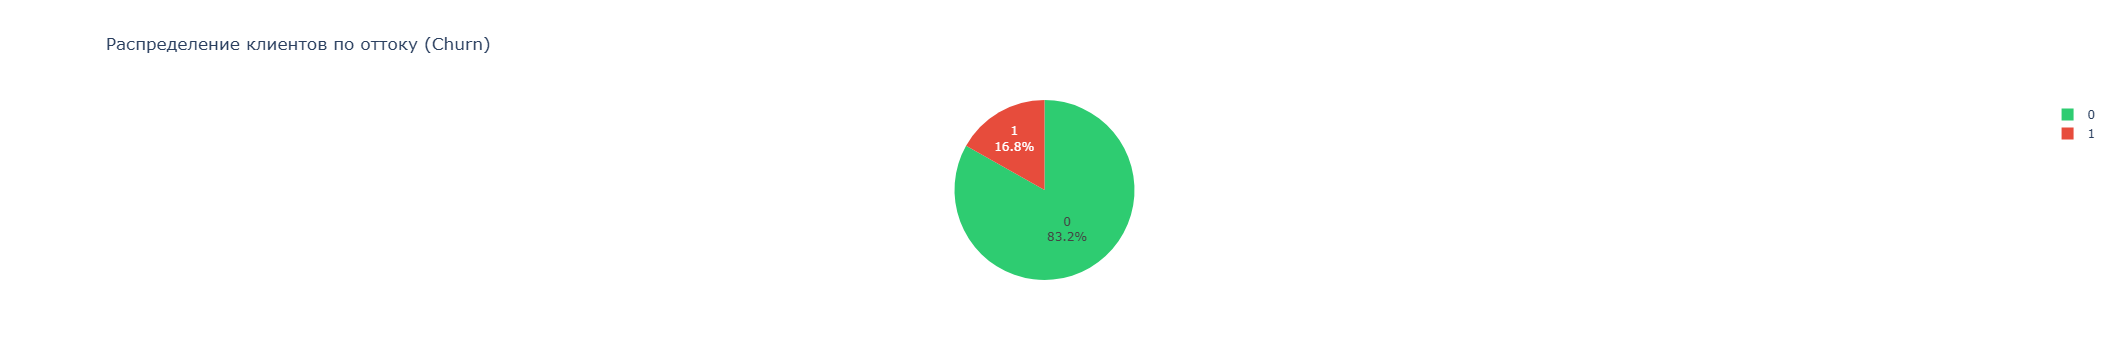

In [20]:
import plotly.express as px

fig1 = px.pie(df, names='Churn', title='Распределение клиентов по оттоку (Churn)',
              labels={0: 'Остались', 1: 'Ушли'}, 
              color_discrete_sequence=['#2ECC71', '#E74C3C'])
fig1.update_traces(textinfo='percent+label')
fig1.show()

#### Гистограмма (Tenure)

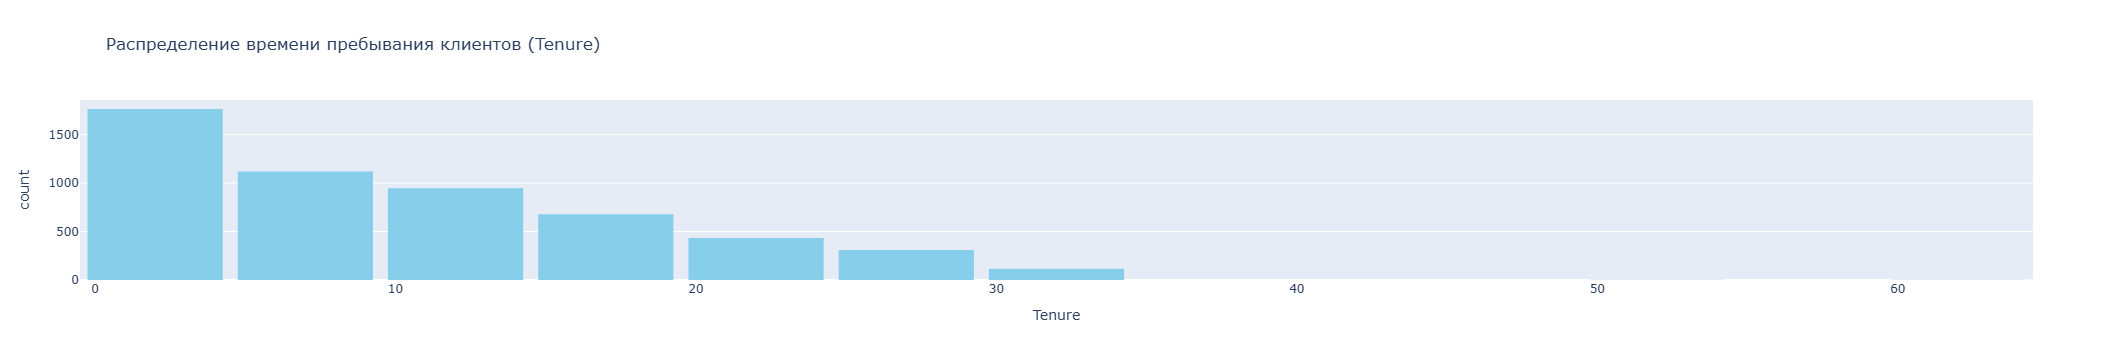

In [21]:
fig2 = px.histogram(df, x='Tenure', nbins=30, color_discrete_sequence=['skyblue'],
                    title='Распределение времени пребывания клиентов (Tenure)')
fig2.update_layout(bargap=0.1)
fig2.show()

#### Столбчатая диаграмма (PreferredLoginDevice)

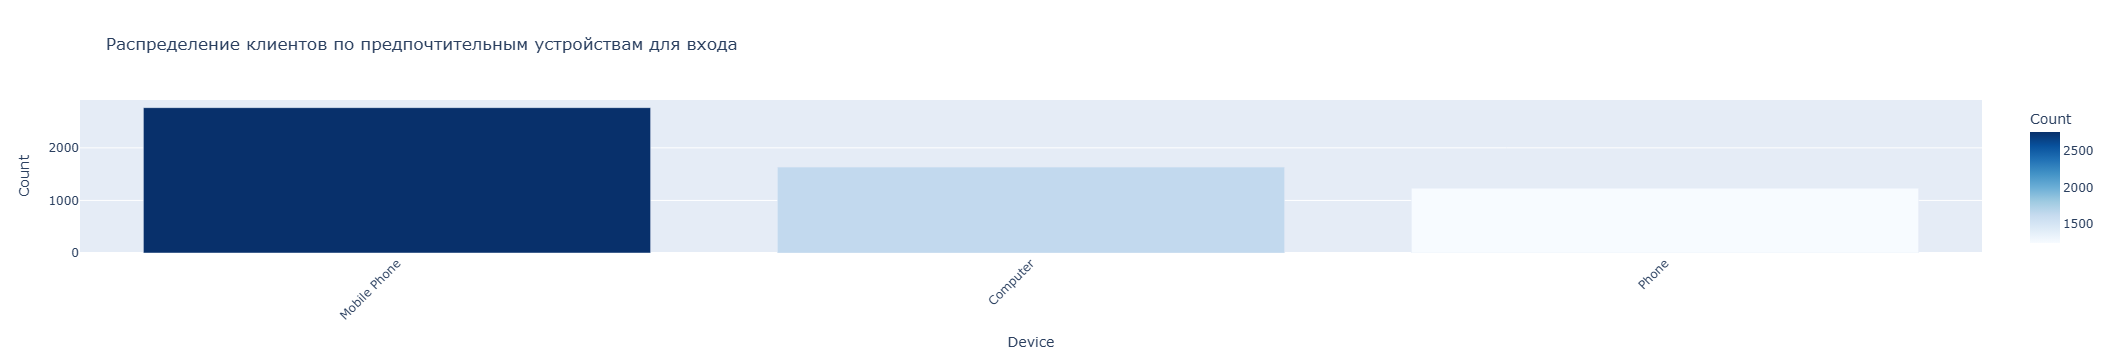

In [22]:
device_counts = df['PreferredLoginDevice'].value_counts().reset_index()
device_counts.columns = ['Device', 'Count']

fig3 = px.bar(device_counts, x='Device', y='Count',
              title='Распределение клиентов по предпочтительным устройствам для входа',
              color='Count', color_continuous_scale='Blues')
fig3.update_layout(xaxis_tickangle=-45)
fig3.show()

#### Линейный график (OrderCount vs Tenure, цвет — Churn)

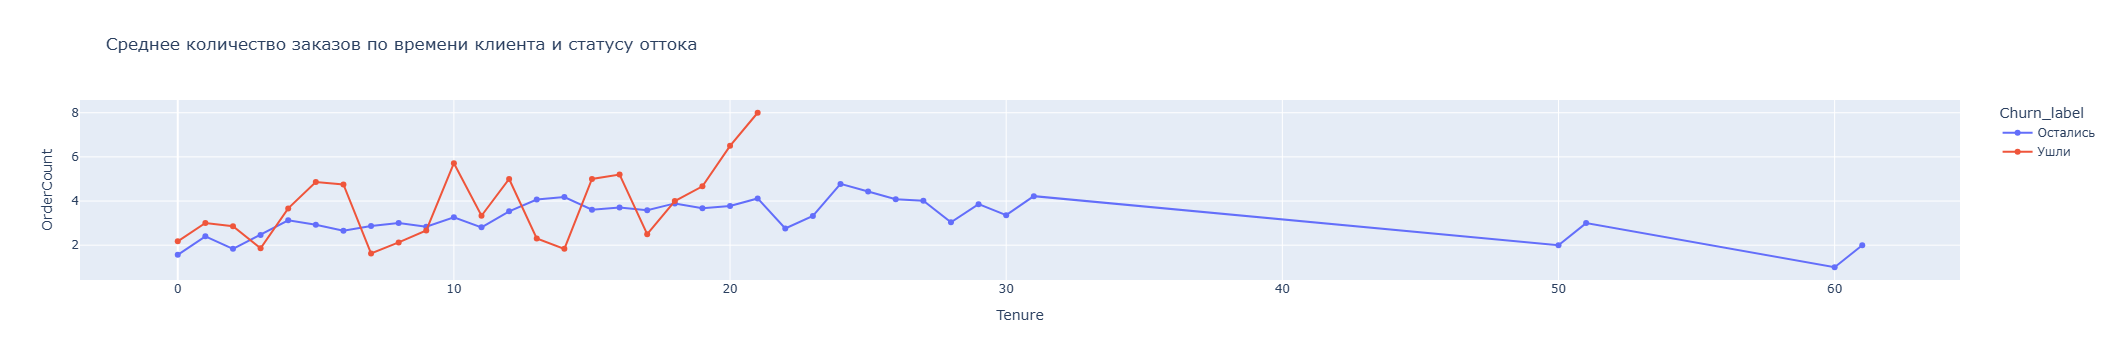

In [23]:
df_clean = df.dropna(subset=['Tenure', 'OrderCount']).copy()
df_clean['Churn_label'] = df_clean['Churn'].map({0: 'Остались', 1: 'Ушли'})

fig4 = px.line(df_clean.groupby(['Churn_label', 'Tenure'])['OrderCount'].mean().reset_index(),
               x='Tenure', y='OrderCount', color='Churn_label',
               title='Среднее количество заказов по времени клиента и статусу оттока',
               markers=True)
fig4.show()

#### Sunburst

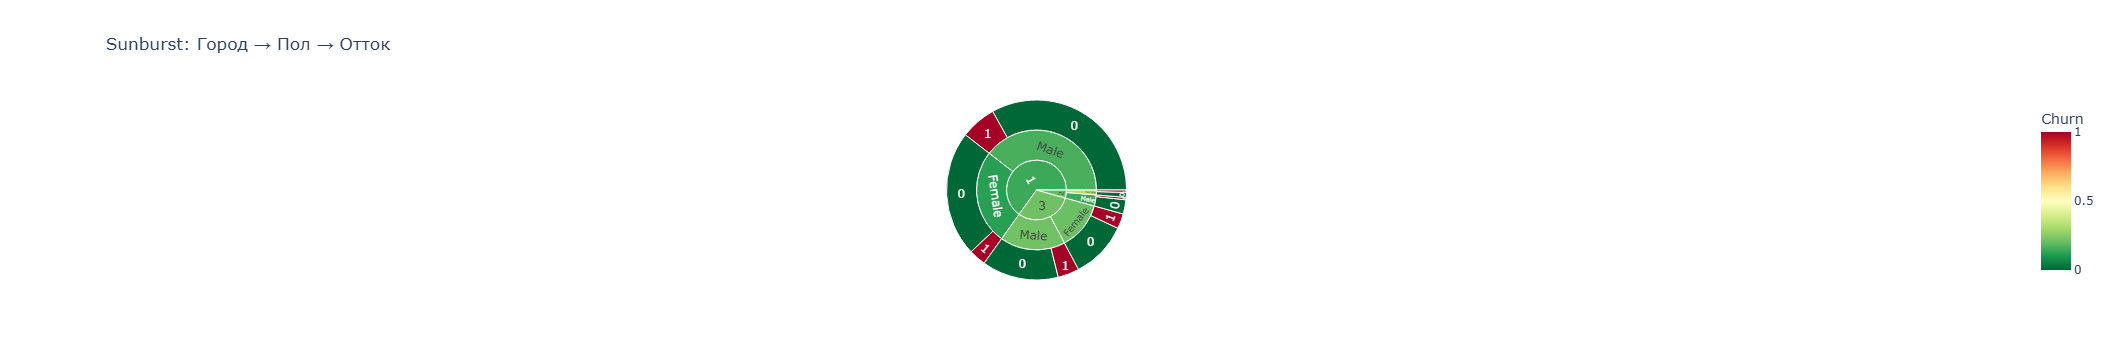

In [24]:
fig6 = px.sunburst(df, path=['CityTier', 'Gender', 'Churn'],
                      title='Sunburst: Город → Пол → Отток',
                      color='Churn', color_continuous_scale='RdYlGn_r')
fig6.show()

#### Гистограмма с накоплением (CouponUsed по MaritalStatus и Churn)

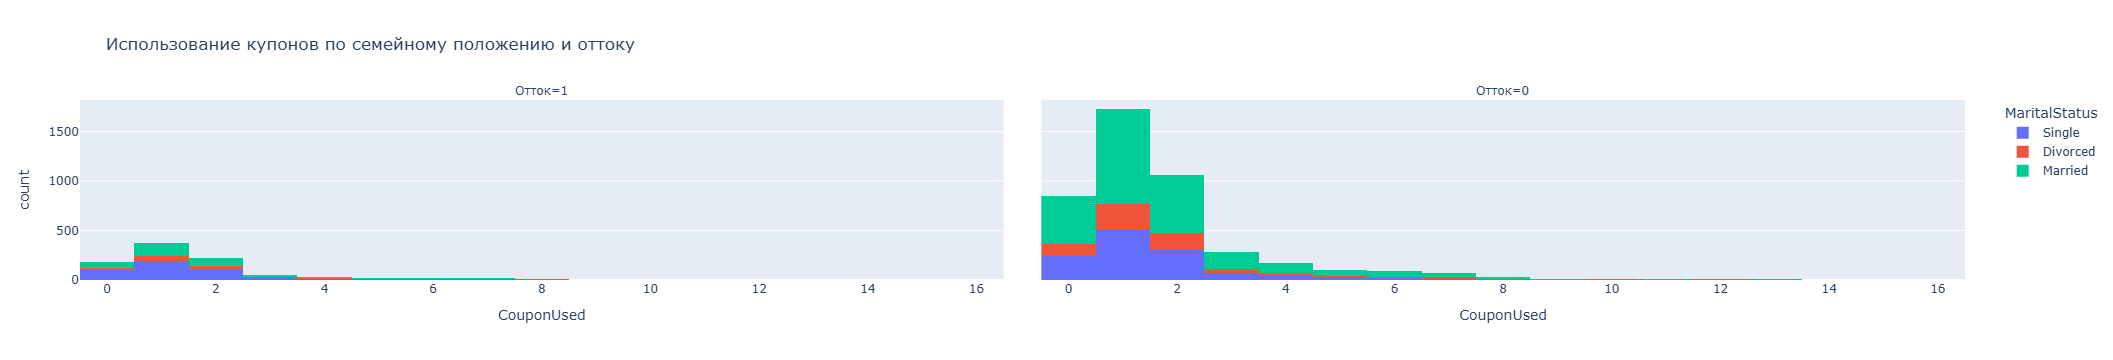

In [25]:
fig5 = px.histogram(df, x='CouponUsed', color='MaritalStatus',
                     facet_col='Churn', 
                     title='Использование купонов по семейному положению и оттоку',
                     labels={'Churn': 'Отток'})
fig5.for_each_annotation(lambda a: a.update(text=a.text.replace("Churn=", "")))
fig5.for_each_trace(lambda t: t.update(name=t.name.split("=")[-1]))
fig5.show()

### Построить несколько суб-графиков на одном графике.

#### Несколько графиков распределений на одном

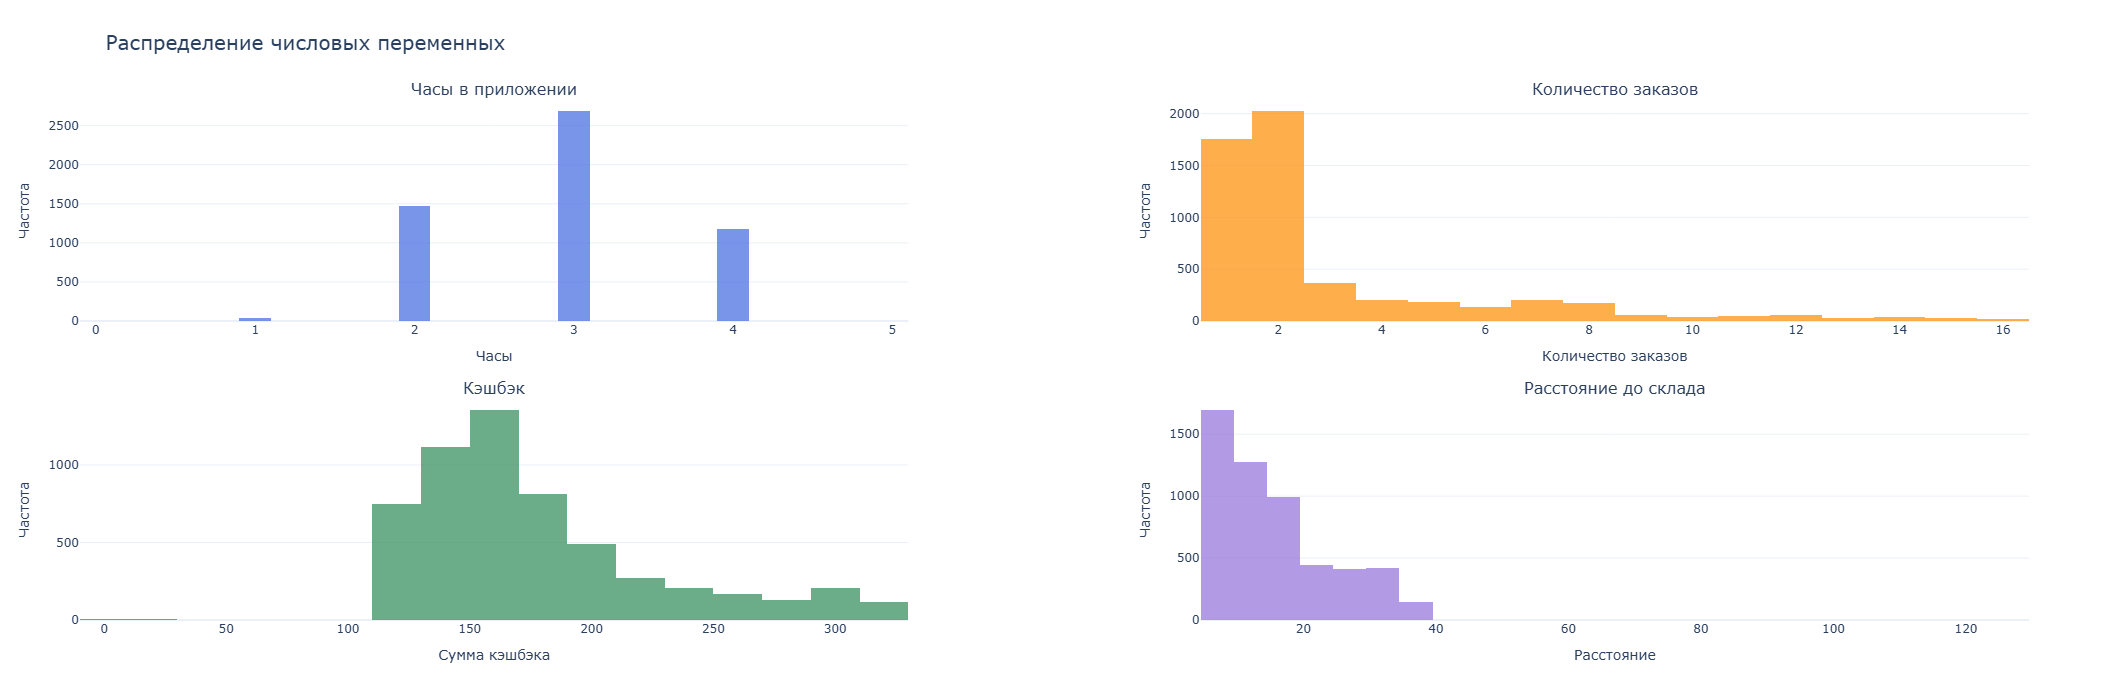

In [26]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

fig2 = make_subplots(
    rows=2, 
    cols=2,
    subplot_titles=('Часы в приложении', 
                    'Количество заказов',
                    'Кэшбэк',
                    'Расстояние до склада'),
    vertical_spacing=0.15,
    horizontal_spacing=0.15
)

# Часы в приложении
fig2.add_trace(
    go.Histogram(
        x=df['HourSpendOnApp'].dropna(),
        nbinsx=30,
        marker_color='royalblue',
        opacity=0.7,
        name='Часы в приложении'
    ),
    row=1, col=1
)

# Количество заказов
fig2.add_trace(
    go.Histogram(
        x=df['OrderCount'].dropna(),
        nbinsx=30,
        marker_color='darkorange',
        opacity=0.7,
        name='Количество заказов'
    ),
    row=1, col=2
)

# Кэшбэк
fig2.add_trace(
    go.Histogram(
        x=df['CashbackAmount'].dropna(),
        nbinsx=30,
        marker_color='seagreen',
        opacity=0.7,
        name='Кэшбэк'
    ),
    row=2, col=1
)

# Расстояние до склада
fig2.add_trace(
    go.Histogram(
        x=df['WarehouseToHome'].dropna(),
        nbinsx=30,
        marker_color='mediumpurple',
        opacity=0.7,
        name='Расстояние до склада'
    ),
    row=2, col=2
)

# Обновление макета
fig2.update_layout(
    title_text='Распределение числовых переменных',
    title_font_size=20,
    showlegend=False,
    height=700,
    width=1000,
    template='plotly_white'
)

# Обновление осей
fig2.update_xaxes(title_text="Часы", row=1, col=1)
fig2.update_yaxes(title_text="Частота", row=1, col=1)

fig2.update_xaxes(title_text="Количество заказов", row=1, col=2)
fig2.update_yaxes(title_text="Частота", row=1, col=2)

fig2.update_xaxes(title_text="Сумма кэшбэка", row=2, col=1)
fig2.update_yaxes(title_text="Частота", row=2, col=1)

fig2.update_xaxes(title_text="Расстояние", row=2, col=2)
fig2.update_yaxes(title_text="Частота", row=2, col=2)

fig2.show()

### Построить интерактивный график.

#### График через go.Figure с несколькими трассами

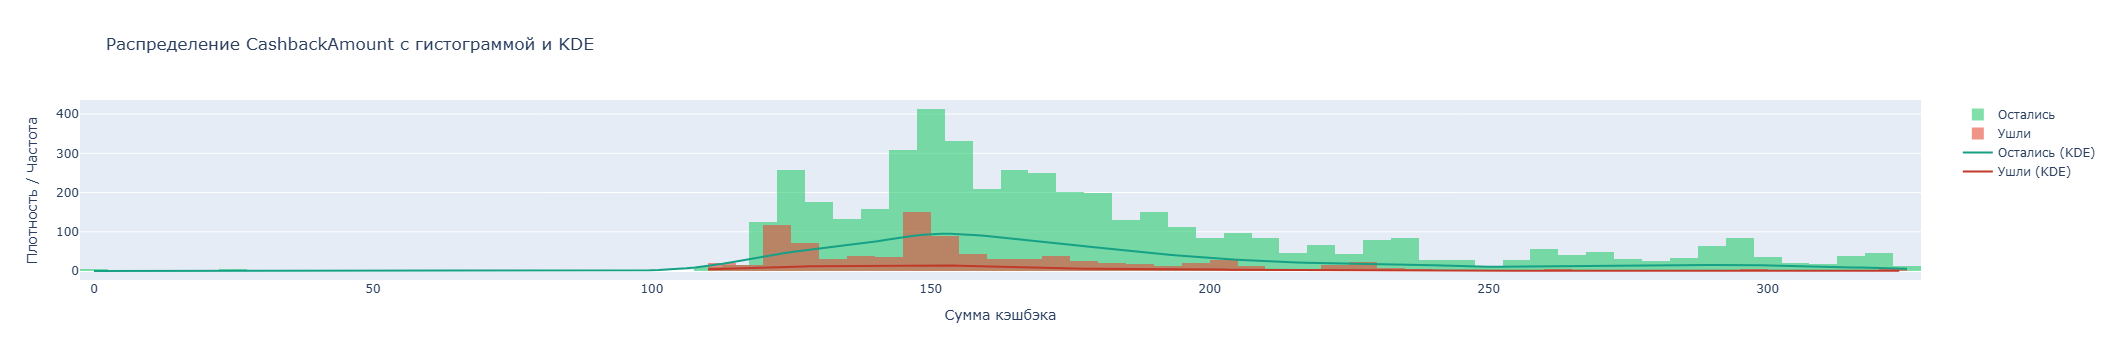

In [27]:
fig_ex4 = go.Figure()

# Гистограммы
for churn_val, name, color in [(0, 'Остались', '#2ECC71'), (1, 'Ушли', '#E74C3C')]:
    subset = df[df['Churn'] == churn_val]['CashbackAmount'].dropna()
    fig_ex4.add_trace(go.Histogram(x=subset, name=name, opacity=0.6, marker_color=color))

# KDE
import numpy as np
from scipy.stats import gaussian_kde

for churn_val, name, color in [(0, 'Остались', '#16A085'), (1, 'Ушли', '#C0392B')]:
    subset = df[df['Churn'] == churn_val]['CashbackAmount'].dropna()
    if len(subset) > 2:
        kde = gaussian_kde(subset)
        x = np.linspace(subset.min(), subset.max(), 200)
        y = kde(x) * len(subset) * (subset.max() - subset.min()) / 200
        fig_ex4.add_trace(go.Scatter(x=x, y=y, mode='lines', name=f'{name} (KDE)', line=dict(color=color, width=2)))

fig_ex4.update_layout(
    title='Распределение CashbackAmount с гистограммой и KDE',
    xaxis_title='Сумма кэшбэка',
    yaxis_title='Плотность / Частота',
    barmode='overlay'
)
fig_ex4.show()

#### Выпадающее меню

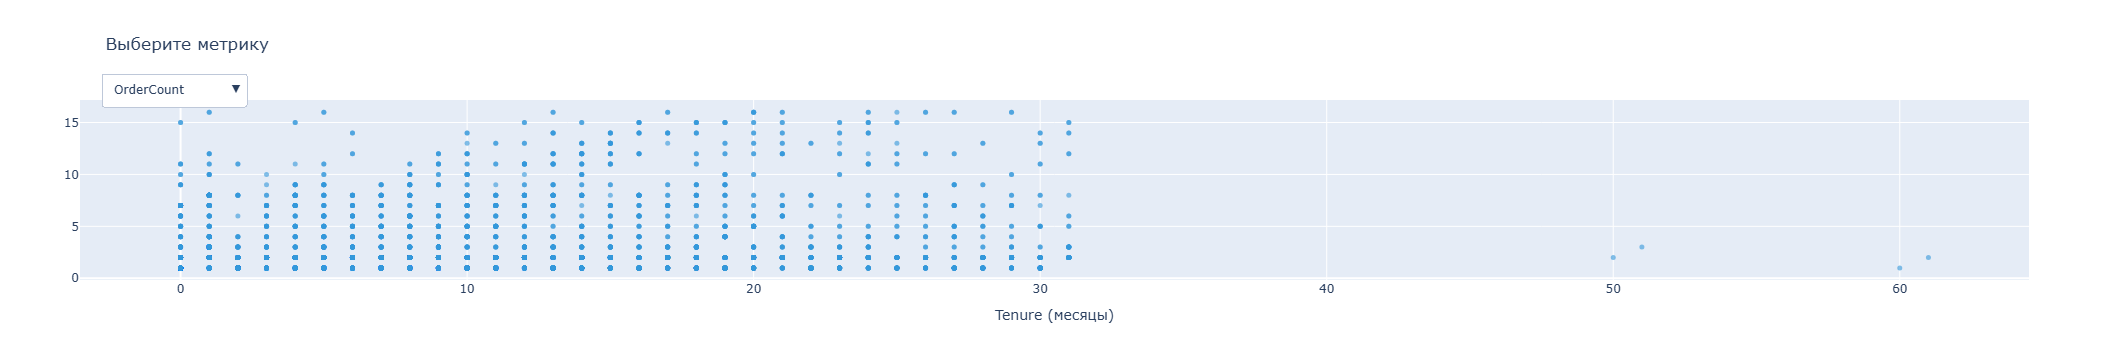

In [28]:
fig_dd = go.Figure()

# Добавляем трассы для каждого показателя
metrics = ['OrderCount', 'CouponUsed', 'CashbackAmount']
colors = ['#3498DB', '#E67E22', '#9B59B6']

for i, metric in enumerate(metrics):
    visible = (i == 0)  # только первая активна по умолчанию
    subset = df.dropna(subset=['Tenure', metric]).copy()
    fig_dd.add_trace(go.Scatter(
        x=subset['Tenure'], y=subset[metric],
        mode='markers',
        name=metric,
        marker=dict(size=5, opacity=0.6, color=colors[i]),
        visible=visible
    ))

# Кнопки переключения
buttons = [
    dict(label=metric,
         method='update',
         args=[{'visible': [j == i for j in range(len(metrics))]},
               {'title': f'Зависимость {metric} от Tenure'}])
    for i, metric in enumerate(metrics)
]

fig_dd.update_layout(
    title='Выберите метрику',
    xaxis_title='Tenure (месяцы)',
    updatemenus=[dict(
        type='dropdown',
        buttons=buttons,
        direction='down',
        showactive=True,
        x=0.085, y=1.15
    )]
)
fig_dd.show()

#### Анимация

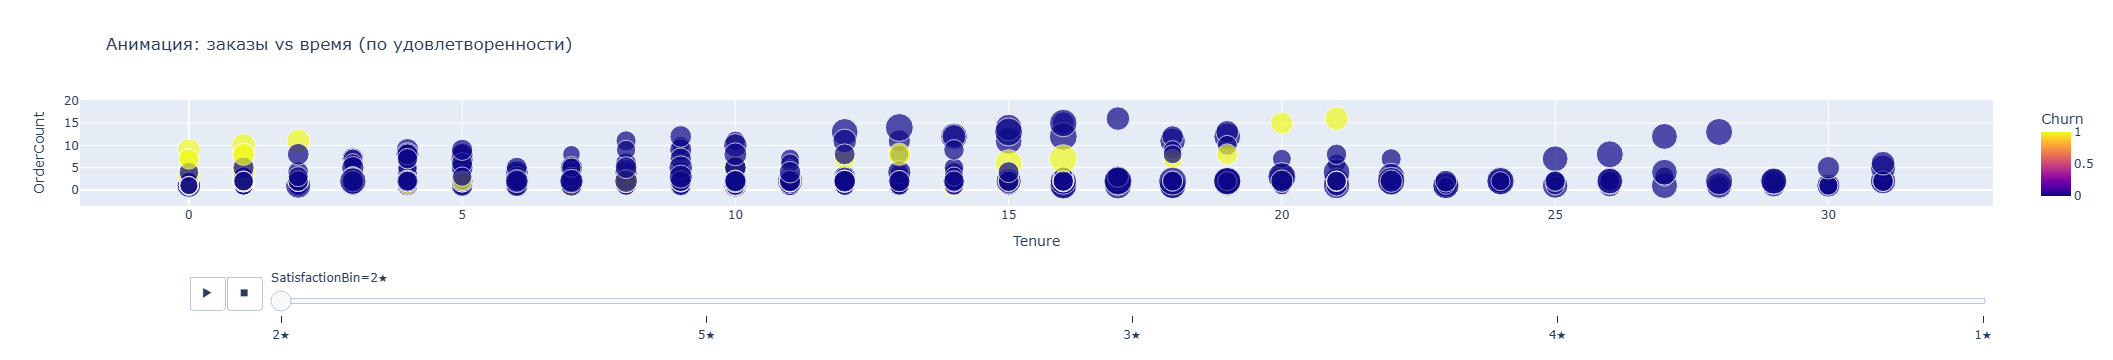

In [29]:
df_anim = df.dropna(subset=['Tenure', 'OrderCount', 'SatisfactionScore']).copy()
df_anim['SatisfactionBin'] = pd.cut(df_anim['SatisfactionScore'], bins=5, labels=['1★', '2★', '3★', '4★', '5★'])

fig_anim = px.scatter(df_anim, x='Tenure', y='OrderCount', 
                      color='Churn', 
                      animation_frame='SatisfactionBin',
                      size='CashbackAmount', 
                      hover_name='CustomerID',
                      title='Анимация: заказы vs время (по удовлетворенности)',
                      color_discrete_map={0: '#2ECC71', 1: '#E74C3C'})
fig_anim.show()